This notebook represent an attempt at predicting weaning trial failure for an invasively ventilated patient using basic machine learning techniques.
It uses a synthetic dataset that was generated using ChatGPT 5.5 with some guidance from me, who is a Registered Respiratory Therapist, with respect to some of the data I would consider useful in the context of such a prediction problem.

The notebook includes explanation of each step I take and why, as well as interpretation of results.

In [38]:
# imports
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    RandomizedSearchCV,
)

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

from scipy.stats import randint, loguniform

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import shap

RANDOM_STATE = 123

In [2]:
# read csv and store in df

df = pd.read_csv('data/synthetic_vent_weaning_trials_with_rt_notes_clean.csv')
df.head()

,patient_id,encounter_id,hospital_site,unit,room_number,rt_id,physio_id,wean_date,charting_system,age,...,actual_wean_minutes_today,trial_stopped_early_today,trial_stopped_reason_today,post_trial_fatigue_score,post_trial_rr,post_trial_spo2,previous_day_post_wean,trial_stopped_reason_t_minus_1,trial_stopped_reason_t_minus_2,trial_stopped_reason_t_minus_3
0,VW100001,E600763,Site_A,CVICU,525,RT_35,PT_07,2026-04-09,Cerner,47,...,34,Yes,fatigue,7,22.1,87.0,RR rose to ~26 bpm with visible fatigue.,anxiety,tachypnea,NaN
1,VW100002,E930323,Site_B,MICU,224,RT_39,PT_19,2026-01-12,Epic,67,...,44,Yes,copious_secretions,2,34.0,100.0,NaN,desaturation,hemodynamic_instability,tachypnea
2,VW100003,E562438,Site_B,Trauma_ICU,611,RT_31,PT_02,2026-03-01,Epic,62,...,47,Yes,desaturation,1,22.3,91.1,Pt anxious during wean; responded somewhat to ...,completed,NaN,NaN
3,VW100004,E290268,Site_A,CVICU,404,RT_18,PT_17,2026-03-18,Epic,41,...,44,Yes,anxiety,4,33.1,95.7,NaN,NaN,anxiety,NaN
4,VW100005,E945552,Site_A,Trauma_ICU,327,RT_02,PT_18,2026-03-29,Epic,81,...,128,Yes,desaturation,3,50.8,86.6,Trial stopped early yesterday due to tachypnea.,tachypnea,NaN,completed


In [3]:
df.describe()

,room_number,age,height_cm,weight_kg,bmi,frailty_score,icu_day,vent_day,days_since_first_weaning_trial,planned_wean_minutes_today,...,fio2_15min,peep_15min,pressure_support_15min,wob_score_15min,dyspnea_borg_15min,rass_15min,actual_wean_minutes_today,post_trial_fatigue_score,post_trial_rr,post_trial_spo2
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,...,1200.000000,1200.000000,1200.000000,1200.000000,1100.000000,1200.000000,1200.000000,1200.000000,1200.00000,1200.000000
mean,523.981667,66.026667,172.256083,86.642667,29.071583,4.548333,8.504167,6.168333,4.742500,118.550000,...,0.379317,6.322500,9.775833,2.353333,4.274545,-0.340000,61.551667,5.138333,27.15225,91.685500
std,201.055620,14.309959,10.997676,23.373723,6.763811,1.799638,3.971330,3.666906,3.672297,91.743728,...,0.089739,2.123421,3.116410,1.330400,2.706291,1.517009,54.218358,2.479446,8.52410,4.929886
min,201.000000,20.000000,140.000000,38.800000,16.000000,1.000000,1.000000,1.000000,0.000000,30.000000,...,0.210000,0.000000,5.000000,0.000000,0.000000,-5.000000,2.000000,0.000000,10.00000,75.500000
25%,327.000000,57.000000,164.900000,69.800000,24.300000,3.000000,5.000000,3.000000,2.000000,60.000000,...,0.320000,5.000000,7.000000,1.000000,2.000000,-1.000000,25.000000,3.000000,21.00000,88.300000
50%,519.000000,66.000000,172.100000,84.700000,29.100000,5.000000,8.000000,6.000000,4.000000,90.000000,...,0.380000,6.000000,10.000000,2.000000,4.000000,0.000000,44.000000,5.000000,27.00000,91.800000
75%,712.000000,76.000000,179.425000,100.900000,33.500000,6.000000,11.000000,9.000000,7.000000,180.000000,...,0.440000,8.000000,12.000000,4.000000,6.000000,1.000000,82.000000,7.000000,32.90000,95.500000
max,830.000000,94.000000,205.000000,197.900000,52.900000,9.000000,23.000000,21.000000,21.000000,480.000000,...,0.660000,13.000000,23.000000,4.000000,10.000000,4.000000,379.000000,10.000000,54.80000,100.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Columns: 228 entries, patient_id to trial_stopped_reason_t_minus_3
dtypes: float64(105), int64(20), object(103)
memory usage: 2.1+ MB


In [5]:
df_dict = pd.read_csv('data/synthetic_vent_weaning_trials_with_rt_notes_clean_data_dictionary.csv')
df_dict.head()

,column,plain_english_meaning,timing,example_values_or_range
0,patient_id,Synthetic patient identifier.,baseline_or_administrative,varies
1,encounter_id,Synthetic hospital encounter identifier.,baseline_or_administrative,varies
2,hospital_site,Hospital site label.,baseline_or_administrative,Site_A; Site_B; Site_C
3,unit,ICU unit caring for the patient.,baseline_or_administrative,CVICU; MICU; Neuro_ICU; SICU; Trauma_ICU
4,room_number,Synthetic ICU room number.,baseline_or_administrative,201.0 to 830.0


In [6]:
unique_timing_cats = df_dict['timing'].unique()
print(f"The {len(unique_timing_cats)} unique timing categories are " + ', '.join(unique_timing_cats))

The 6 unique timing categories are baseline_or_administrative, planned_trial, outcome_or_after_trial, early_trial, prior_weaning_history, pre_trial_or_recent


We can see that we have a large number of features to work with, and from the data dictionary we see that they fall into 7 categories.

It seems like we can answer a variety of questions using this dataset, so for simplicity I will focus on just one: given clinical data for a tracheostomized patient as well as data pertaning to their prior weaning history, can we predict whether or not they will fail their next wean? This is a useful consideration for clinicians that need to consider which of their weaning patients they may need to pay closer attention to.

I will define weaning failure as a patient completing <75% of their planned wean. 

There are a number of features that are capturing information during and after the wean. In the context of this prediction problem, these would leak information to the model and likely bias the results in a way that causes the model to perform well on training data but fails to generalize. These features will need to be removed from the dataset.

One consideration fundamental to removing all features whose time basis is before the start of the wean is the impact of the weaning parameters themselves on weaning trial failure. Undoubtedly, changes to weaning settings that dramatically increase the difficulty of the current wean or a dramatic increase in the planned weaning time are likely to increase the odds of weaning failure. These will not be considered in this exercise, which seems reasonable given that some weaning successes may be due to settings or a planned duration that are overly conservative. 

In [7]:
# keep only examples with tracheostomy
df = df[df["airway_type"] == "tracheostomy"]

# create the target 
df['did_fail_wean'] = (df['actual_wean_minutes_today'] / df['planned_wean_minutes_today']) < 0.75
df['did_fail_wean'].head()

0      True
2     False
6     False
9      True
12    False
Name: did_fail_wean, dtype: bool

In [8]:
# split the data into training and test

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE
) 

I will do some exploratory data visualization. There are a large number of features in the dataset and so for simplicity, I have selected explorations that I feel would be useful in using my clinical experience. 

In [9]:
# Proportion of weaning failure by primary diagnosis

disease_cols = [
    'copd',
    'asthma',
    'chf',
    'ischemic_heart_disease',
    'renal_failure',
    'obesity',
]

proportions = []
counts = []

for disease in disease_cols:
    has_disease = train_df[disease] == 'Yes'
    has_disease_did_fail_wean = train_df.loc[has_disease, 'did_fail_wean'] 
    counts.append(len(has_disease_did_fail_wean))
    proportions.append(has_disease_did_fail_wean.sum() / len(has_disease_did_fail_wean))

has_nmd = train_df['neuromuscular_disease'] != 'none'
has_nmd_did_fail_wean = train_df.loc[has_nmd, 'did_fail_wean'] 
counts.append(len(has_nmd_did_fail_wean))
proportions.append(has_nmd_did_fail_wean.sum() / len(has_nmd_did_fail_wean))

props_by_disease_df = pd.DataFrame(proportions, index=disease_cols+['neuromuscular_disease'], columns=['proportions'])

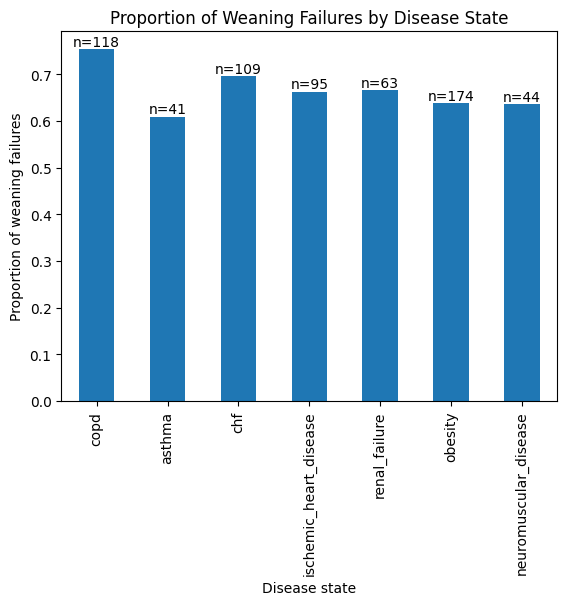

In [10]:
ax = props_by_disease_df.plot.bar(
  title="Proportion of Weaning Failures by Disease State",
  legend=False,
  xlabel="Disease state",
  ylabel="Proportion of weaning failures",
)

for bar, count in zip(ax.patches, counts):
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height(),
      f"n={count}",
      ha="center",
      va="bottom",
  )

It appears as though we have minor differences in the proportion of weaning failures seen by disease state, a reasonable number of observations in each bin, and minor class imbalance.


<Axes: title={'center': 'Hours of Sleep Last Night vs. Percentage of Weaning Trial Completed'}, xlabel='Hours of Sleep Last Night', ylabel='Percentage of Weaning Trial Completed'>

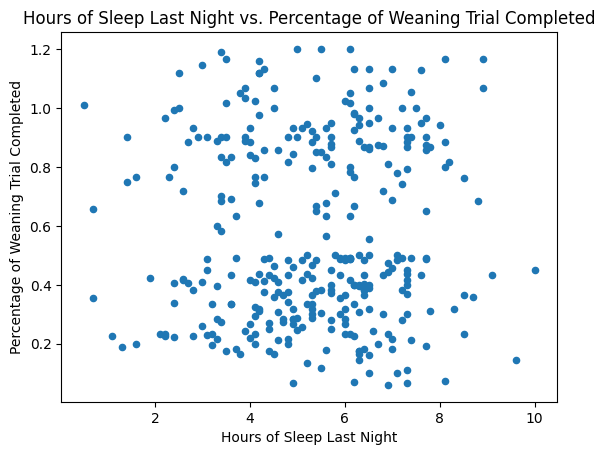

In [11]:
# Sleep hours last night vs percentage of trial completed
percent_trial_completed = train_df['actual_wean_minutes_today'] / train_df['planned_wean_minutes_today']

sleep_trial_df = pd.DataFrame({
  "sleep_hours_last_night": train_df["sleep_hours_last_night"],
  "percent_trial_completed": percent_trial_completed,
})

sleep_trial_df.plot.scatter(
    x="sleep_hours_last_night",
    y="percent_trial_completed",
    title="Hours of Sleep Last Night vs. Percentage of Weaning Trial Completed",
    legend=False,
    xlabel="Hours of Sleep Last Night",
    ylabel="Percentage of Weaning Trial Completed",
)

There appears to be no correlation between a given patient's hours of sleep last night and percentage of weaning trial completed. Percentage of weaning trial completed was chosen as the variable as opposed to our binary target as I thought it may be more visually illustrative. This does not mean that this feature should be dropped from the training pipeline; it is possible that it may offer predictive value in this context when combined with another feature, which some models (e.g., decision trees) are capable of doing without explicit feature engineering. 

In [12]:
# attempt clustering of observations using previous day's post wean comments
import spacy
import re

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def regex_preprocessing(doc: str) -> str:
    return re.sub(r"[^a-zA-Z\s]", " ", doc) # remove anything that is not a letter or whitespace

def spacy_preprocessing(
    doc,
    min_token_len=2,
    irrelevant_pos=["ADV", "PRON", "CCONJ", "PUNCT", "PART", "DET", "ADP", "SPACE"],
):
    clean_text = []
    for token in doc:
        if (
            token.is_stop == False
            and len(token) > min_token_len
            and token.pos_ not in irrelevant_pos
        ):
            lemma = token.lemma_ 
            clean_text.append(lemma.lower())
            
    return " ".join(clean_text)

In [13]:
# preprocess the comments
regex_series = train_df['previous_day_post_wean'].fillna("").apply(regex_preprocessing)
train_df["previous_day_post_wean_pp"] = [spacy_preprocessing(doc) for doc in nlp.pipe(regex_series)]

# convert to bag of words representation
vec = CountVectorizer(stop_words="english") 
post_wean_comments_bow = vec.fit_transform(train_df["previous_day_post_wean_pp"])

In [14]:
n_topics_range = range(2, 5, 1)

for n_topics in n_topics_range:
    print(f"Number of topics: {n_topics}")
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=RANDOM_STATE, learning_method="batch")
    lda.fit(post_wean_comments_bow)

    feature_names = vec.get_feature_names_out()
    
    for topic_idx, topic_weights in enumerate(lda.components_):
        print(f"Topic {topic_idx + 1}:")
        top_word_indices = topic_weights.argsort()[-10:][::-1] # sort from low to high, grab 10 highest, then reverse the list
        top_words = [feature_names[i] for i in top_word_indices]
        print(", ".join(top_words))
        print("-" * 20)

Number of topics: 2
Topic 1:
tachypnea, note, wean, remain, increase, wob, acceptable, spo, end, mild
--------------------
Topic 2:
trial, stop, fatigue, wean, plan, bpm, yesterday, early, end, complete
--------------------
Number of topics: 3
Topic 1:
wean, remain, note, increase, tachypnea, wob, acceptable, spo, end, mild
--------------------
Topic 2:
trial, fatigue, stop, wean, bpm, yesterday, early, end, feel, fine
--------------------
Topic 3:
plan, complete, encouragement, required, time, tolerate, duration, wean, comfortable, coach
--------------------
Number of topics: 4
Topic 1:
note, increase, remain, tachypnea, wob, acceptable, spo, mild, recover, end
--------------------
Topic 2:
trial, stop, fatigue, yesterday, early, desaturation, tachypnea, limit, note, rise
--------------------
Topic 3:
plan, complete, encouragement, time, required, tolerate, duration, issue, distress, wean
--------------------
Topic 4:
wean, end, bpm, report, feel, fine, anxious, shortness, breath, rea

Considering that one of the simplest ways of describing a weaning trial is in binary terms—that is, the patient either tolerated or did not tolerate the wean—it seems reasonable that the a clinician's post-wean comments fall most naturally into 2 categories. Looking at the results above, for `n_components=2`, topic 1 appears to be associated with "not tolerated" and topic 2 appears to be associated with "tolerated." `n_components=3` does not appear to clearly introduce a meaningfully different category (e.g., tolerated with difficulty or signficant encouragement). In light of this I will select the simpler model.

In [15]:
lda = LatentDirichletAllocation(n_components=2, random_state=RANDOM_STATE, learning_method="batch")
document_topics = lda.fit_transform(post_wean_comments_bow)

import mglearn

sorting = np.argsort(lda.components_, axis=1)[:, ::-1]

mglearn.tools.print_topics(
    topics=range(2),
    feature_names=feature_names,
    sorting=sorting,
    topics_per_chunk=5,
    n_words=10,
)

topic 0       topic 1       
--------      --------      
tachypnea     trial         
note          stop          
wean          fatigue       
remain        wean          
increase      plan          
wob           bpm           
acceptable    yesterday     
spo           early         
end           end           
mild          complete      




The post-wean comments appear to have at least 2 meaningful categories. To use this in the context of our supervised machine-learning problem, we need to create a binary feature from our comments. Notably, in the event of ties we would prefer a false positive; that is, we would rather predict that a patient would fail their wean because in a clinical context we tend to err on the side of caution. Topic 0 appears to be the "did not tolerate" category.

In [16]:
document_topics.shape
document_topics[:5]

array([[0.5       , 0.5       ],
       [0.5       , 0.5       ],
       [0.91441574, 0.08558426],
       [0.08038925, 0.91961075],
       [0.08371944, 0.91628056]])

In [17]:
comment_topic = np.where(
  document_topics[:, 0] >= document_topics[:, 1],
  0,
  1,
)
train_df["previous_wean_comment_topic"] = comment_topic

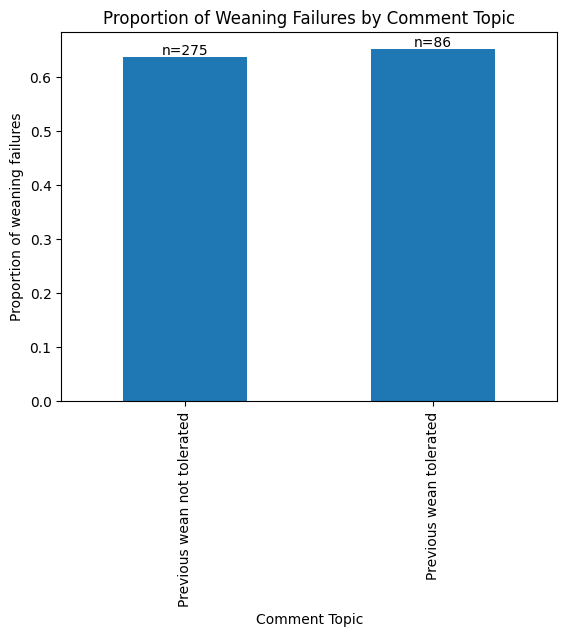

In [18]:
props_by_wean_comment = train_df.groupby(
  "previous_wean_comment_topic"
)["did_fail_wean"].agg(["mean", "count"])
props_by_wean_comment

props_by_wean_comment = props_by_wean_comment.rename(index={
  0: "Previous wean not tolerated",
  1: "Previous wean tolerated",
})

ax = props_by_wean_comment['mean'].plot.bar(
  title="Proportion of Weaning Failures by Comment Topic",
  legend=False,
  xlabel="Comment Topic",
  ylabel="Proportion of weaning failures",
)

for bar, count in zip(ax.patches, props_by_wean_comment['count']):
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height(),
      f"n={count}",
      ha="center",
      va="bottom",
  )

In [19]:
train_df["did_fail_wean"].mean()

np.float64(0.6398891966759003)

The bar graph does not appear to make clinical sense if we assume that our topic assignment was reasonable. If a patient tolerated their previous wean, I would expect most of those patient's to tolerate today's wean. Here, a greater proportion of patient's labelled as having tolerated their previous wean failing today's wean. Notably, our synthetic data has an overall failure rate of 64%. In any case, it seems as though the way I have encoded previous weaning comments does not appear to provide any discrimination in terms of our target. If it had, we should have seen a proportion of weaning failures higher than the overall average for the "previous wean not tolerated" label and lower than the average for the "previous wean tolerated" label.

In [20]:
# Preprocessing
# Drop any rows missing these, since they are used to derive the target class
print('missing values in actual wean minutes', df['actual_wean_minutes_today'].isnull().sum())
print('missing values in planned wean minutes', df['planned_wean_minutes_today'].isnull().sum())

missing values in actual wean minutes 0
missing values in planned wean minutes 0


In [21]:
# Feature groups for preprocessing
numeric_feats = [
    "age",
    "completion_percent_t_minus_1",
    "avg_rr_during_wean_t_minus_1",
    "avg_hr_during_wean_t_minus_1",
    "avg_spo2_during_wean_t_minus_1",
    "max_wob_score_t_minus_1",
    "sleep_hours_last_night",
    "pain_score_morning",
]

numeric_pipe = make_pipeline(
    SimpleImputer(strategy="mean"), 
    StandardScaler()
)

ordinal_feats = [
    "accessory_muscle_use_t_minus_1",
    "anxiety_during_wean_t_minus_1",
    "diaphoresis_t_minus_1",
    "secretion_burden_morning",
    "anxiety_morning",
]

ordinal_categories = [
    ["none", "mild", "moderate", "severe"],
    ["none", "mild", "moderate", "severe"],
    ["none", "mild", "moderate", "severe"],
    ["minimal", "mild", "moderate", "copious"],
    ["none", "mild", "moderate", "severe"],
]

ordinal_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder(categories=ordinal_categories),
    StandardScaler()
)

categorical_feats = [
    "sex",
    "obesity",
    "smoking_status",
    "copd",
    "asthma",
    "chf",
    "ischemic_heart_disease",
    "renal_failure",
    "neuromuscular_disease",
    "home_oxygen",
    "physio_during_wean_t_minus_1",
]

categorical_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
)

def fill_missing_text(s):
    return s.fillna("")

text_pipe = make_pipeline(
    FunctionTransformer(fill_missing_text, validate=False),
    CountVectorizer(stop_words="english", binary=True, max_features=100)
)


In [22]:
y_train = train_df['did_fail_wean']
X_train = train_df.drop(columns='did_fail_wean')

In [23]:
train_df["previous_day_post_wean"].dtype

dtype('O')

In [24]:
# Preprocessing



ct = ColumnTransformer(
    [
        ("numeric", numeric_pipe, numeric_feats),
        ("ordinal", ordinal_pipe, ordinal_feats),
        ("categorical", categorical_pipe, categorical_feats),
        ("text", text_pipe, "previous_day_post_wean"),
    ]
)

In [25]:
def mean_std_cross_val_scores(model, X_train, y_train, **kwargs):
    """
    Returns mean and std of cross validation

    Parameters
    ----------
    model :
        scikit-learn model
    X_train : numpy array or pandas DataFrame
        X in the training data
    y_train :
        y in the training data

    Returns
    ----------
        pandas Series with mean scores from cross_validation
    """

    scores = cross_validate(model, X_train, y_train, **kwargs)

    mean_scores = pd.DataFrame(scores).mean()
    std_scores = pd.DataFrame(scores).std()
    out_col = []

    for i in range(len(mean_scores)):
        out_col.append((f"%0.3f (+/- %0.3f)" % (mean_scores.iloc[i], std_scores.iloc[i])))

    return pd.Series(data=out_col, index=mean_scores.index)

results_dict = {}

In [26]:
# Baseline
dummy = DummyClassifier(strategy="most_frequent")

results_dict["dummy"] = mean_std_cross_val_scores(
    dummy, X_train, y_train, return_train_score=True
)
pd.DataFrame(results_dict)

,dummy
fit_time,0.001 (+/- 0.000)
score_time,0.000 (+/- 0.000)
test_score,0.640 (+/- 0.002)
train_score,0.640 (+/- 0.001)


Now, I will train 3 different models:

1. Logistic Regressor: a linear classification model that is simple and interpretable, which is important in a clinical context and gives us a baseline against which to compare more complex, less interpretable models for the performance-interpretability tradeoff.
2. Random Forest Classifier: a tree-based ensemble that makes decision using an ensemble of paraellel decision trees
3. XGBoost: a tree-based ensemble that uses a series of decision-trees to progressively reduce prediction error

Because of the inclusion of free text and a Count Vectorizer in our preprocessing step, I think a similarity-based model like KNN or RBF SVM will be harmed by the curse of dimensionality due to the high number of features, many of which are of dubious predictive value. A linear model like logistic regression handles this much more gracefully since features explaining little of the target variance will be assigned a correspondingly low weight.

In [27]:
# Logistic Regressor
scores_dict = {
    "C": 10.0 ** np.arange(-4, 6, 1),
    "mean_train_scores": list(),
    "mean_cv_scores": list(),
}

for C in scores_dict["C"]:
    lr = LogisticRegression(C=C, max_iter=1000)
    pipe_lr = make_pipeline(ct, lr)
    scores = cross_validate(pipe_lr, X_train, y_train, return_train_score=True)
    scores_dict["mean_train_scores"].append(scores["train_score"].mean())
    scores_dict["mean_cv_scores"].append(scores["test_score"].mean())

results_df = pd.DataFrame(scores_dict)
results_df

,C,mean_train_scores,mean_cv_scores
0,0.0001,0.639889,0.639878
1,0.0010,0.639889,0.639878
2,0.0100,0.660674,0.650989
3,0.1000,0.722991,0.628843
4,1.0000,0.746535,0.623135
5,10.0000,0.756231,0.606507
6,100.0000,0.756233,0.612100
7,1000.0000,0.753463,0.609323
8,10000.0000,0.754155,0.612100
9,100000.0000,0.755541,0.612100


In [28]:
best_validation_idx = results_df["mean_cv_scores"].idxmax()
best_C = results_df.loc[best_validation_idx, "C"]
lr = LogisticRegression(C=best_C, max_iter=1000)
best_pipe_lr = make_pipeline(ct, lr)

results_dict["logistic_regression"] = mean_std_cross_val_scores(
    best_pipe_lr, X_train, y_train, return_train_score=True
)
pd.DataFrame(results_dict)

,dummy,logistic_regression
fit_time,0.001 (+/- 0.000),0.009 (+/- 0.001)
score_time,0.000 (+/- 0.000),0.004 (+/- 0.000)
test_score,0.640 (+/- 0.002),0.651 (+/- 0.030)
train_score,0.640 (+/- 0.001),0.661 (+/- 0.012)


In [29]:
# Random forest
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)

pipe_rf = make_pipeline(ct, rf)
param_distributions = {
  "randomforestclassifier__n_estimators": randint(100, 501),
  "randomforestclassifier__max_depth": randint(3, 31),
  "randomforestclassifier__max_features": ["sqrt", "log2", None],
}

rf_search = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_distributions,
    n_iter=30,
    cv=3,
    n_jobs=-1,
    return_train_score=True,
    random_state=RANDOM_STATE,
)
rf_search.fit(X_train, y_train)
rf_hpo_results = pd.DataFrame(rf_search.cv_results_)[
    [
        "mean_test_score",
        "param_randomforestclassifier__n_estimators",
        "param_randomforestclassifier__max_depth",
        "mean_fit_time",
        "rank_test_score",
    ]
].set_index("rank_test_score").sort_index().T
rf_hpo_results

rank_test_score,1,2,3,3,5,6,7,8,9,10,...,21,21,21,24,25,26,27,28,29,30
mean_test_score,0.681451,0.675987,0.675895,0.675895,0.667700,0.66483,0.664807,0.664784,0.662075,0.659481,...,0.648416,0.648416,0.648416,0.648393,0.645592,0.642860,0.642837,0.642700,0.639899,0.626079
param_randomforestclassifier__n_estimators,132.000000,371.000000,276.000000,211.000000,117.000000,118.00000,412.000000,151.000000,258.000000,176.000000,...,355.000000,422.000000,453.000000,184.000000,353.000000,465.000000,308.000000,411.000000,226.000000,199.000000
param_randomforestclassifier__max_depth,18.000000,21.000000,18.000000,17.000000,5.000000,20.00000,26.000000,20.000000,14.000000,30.000000,...,9.000000,16.000000,23.000000,10.000000,28.000000,23.000000,22.000000,7.000000,3.000000,10.000000
mean_fit_time,0.130821,0.325399,0.241373,0.205025,0.179422,0.11440,0.317506,0.124992,0.207918,0.324278,...,0.597233,0.741009,0.783214,0.320736,0.650787,0.844728,0.515317,0.341301,0.158138,0.162157


In [30]:
best_pipe_rf = rf_search.best_estimator_

results_dict["rand_forest"] = mean_std_cross_val_scores(
    best_pipe_rf, X_train, y_train, return_train_score=True
)
pd.DataFrame(results_dict)

,dummy,logistic_regression,rand_forest
fit_time,0.001 (+/- 0.000),0.009 (+/- 0.001),0.096 (+/- 0.003)
score_time,0.000 (+/- 0.000),0.004 (+/- 0.000),0.012 (+/- 0.000)
test_score,0.640 (+/- 0.002),0.651 (+/- 0.030),0.640 (+/- 0.041)
train_score,0.640 (+/- 0.001),0.661 (+/- 0.012),1.000 (+/- 0.000)


In [31]:
# XGBoost
xgb_clf = XGBClassifier(
    objective="binary:logistic",
    random_state=RANDOM_STATE,
    verbosity=0,
    n_jobs=1,
)
pipe_xgb = make_pipeline(ct, xgb_clf)

param_distributions = {
    "xgbclassifier__n_estimators": randint(50, 251),
    "xgbclassifier__max_depth": randint(2, 8),
    "xgbclassifier__learning_rate": loguniform(0.01, 0.3),
    "xgbclassifier__subsample": [0.6, 0.8, 1.0],
    "xgbclassifier__colsample_bytree": [0.6, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_distributions,
    n_iter=30,
    cv=3,
    n_jobs=-1,
    return_train_score=True,
    random_state=RANDOM_STATE,
)
xgb_search.fit(X_train, y_train)
xgb_hpo_results = pd.DataFrame(xgb_search.cv_results_)[
    [
        "mean_test_score",
        "param_xgbclassifier__n_estimators",
        "param_xgbclassifier__max_depth",
        "param_xgbclassifier__learning_rate",
        "mean_fit_time",
        "rank_test_score",
    ]
].set_index("rank_test_score").sort_index().T
xgb_hpo_results

rank_test_score,1,2,3,4,5,6,7,8,9,10,...,21,22,23,23,25,26,27,28,29,30
mean_test_score,0.673209,0.662259,0.659458,0.653926,0.653880,0.653834,0.651194,0.651148,0.651079,0.648439,...,0.634573,0.634504,0.634481,0.634481,0.631795,0.629040,0.626217,0.623439,0.623393,0.609573
param_xgbclassifier__n_estimators,158.000000,136.000000,169.000000,127.000000,243.000000,65.000000,181.000000,233.000000,99.000000,107.000000,...,239.000000,62.000000,53.000000,128.000000,173.000000,148.000000,165.000000,171.000000,82.000000,171.000000
param_xgbclassifier__max_depth,6.000000,3.000000,2.000000,4.000000,5.000000,6.000000,2.000000,7.000000,6.000000,5.000000,...,3.000000,3.000000,4.000000,5.000000,4.000000,4.000000,7.000000,2.000000,3.000000,5.000000
param_xgbclassifier__learning_rate,0.010142,0.028133,0.014336,0.022687,0.084435,0.042560,0.027155,0.051701,0.038722,0.115543,...,0.053724,0.080412,0.047279,0.119370,0.177989,0.113011,0.248107,0.105130,0.102701,0.175486
mean_fit_time,0.039766,0.028826,0.024783,0.027859,0.050856,0.029643,0.026963,0.058650,0.032132,0.029924,...,0.037243,0.017340,0.028278,0.030483,0.031636,0.034936,0.040677,0.024874,0.020176,0.038993


In [32]:
best_pipe_xgb = xgb_search.best_estimator_

results_dict["xgb"] = mean_std_cross_val_scores(
    best_pipe_xgb, X_train, y_train, return_train_score=True
)
pd.DataFrame(results_dict)

,dummy,logistic_regression,rand_forest,xgb
fit_time,0.001 (+/- 0.000),0.009 (+/- 0.001),0.096 (+/- 0.003),0.040 (+/- 0.002)
score_time,0.000 (+/- 0.000),0.004 (+/- 0.000),0.012 (+/- 0.000),0.005 (+/- 0.000)
test_score,0.640 (+/- 0.002),0.651 (+/- 0.030),0.640 (+/- 0.041),0.657 (+/- 0.033)
train_score,0.640 (+/- 0.001),0.661 (+/- 0.012),1.000 (+/- 0.000),0.861 (+/- 0.006)


We can see that none of the models is performing significantly better than our dummy classifier. XGB has the best validation score, but is a significantly more complex and less interpretable model compared to a logistic regression classifier.

Ignoring the fact that this is a synthetic dataset, the most likely reason for the poor model performance is the quality of the features that these models have to train on. The highest priority action I would take to improve the results is go back and perform further exploratory data analysis and feature engineering to discern features that appear to have some correlation with the target variable, and perhaps fine tune the features included using a feature selection process like RFECV. 

In [37]:
# Inspect feature importance of Linear Regression

best_pipe_lr.fit(X_train, y_train)

preprocessor = best_pipe_lr.named_steps["columntransformer"]

numeric_names = numeric_feats
ordinal_names = ordinal_feats

categorical_names = (
  preprocessor
  .named_transformers_["categorical"]
  .named_steps["onehotencoder"]
  .get_feature_names_out(categorical_feats)
)

text_names = (
  preprocessor
  .named_transformers_["text"]
  .named_steps["countvectorizer"]
  .get_feature_names_out()
)

text_names = ["text_" + name for name in text_names]

feature_names = (
  list(numeric_names)
  + list(ordinal_names)
  + list(categorical_names)
  + list(text_names)
)

coefs = best_pipe_lr.named_steps["logisticregression"].coef_[0]

lr_coefs = pd.DataFrame({
  "feature": feature_names,
  "coefficient": coefs,
  "abs_coefficient": np.abs(coefs),
})

lr_coefs.sort_values("abs_coefficient", ascending=False).head(20)

,feature,coefficient,abs_coefficient
0,age,0.179661,0.179661
3,avg_hr_during_wean_t_minus_1,0.149925,0.149925
8,accessory_muscle_use_t_minus_1,0.092749,0.092749
22,copd_Yes,0.089727,0.089727
21,copd_No,-0.089726,0.089726
11,secretion_burden_morning,0.079135,0.079135
1,completion_percent_t_minus_1,-0.070548,0.070548
7,pain_score_morning,0.064434,0.064434
2,avg_rr_during_wean_t_minus_1,0.050545,0.050545
19,smoking_status_former,0.047980,0.047980


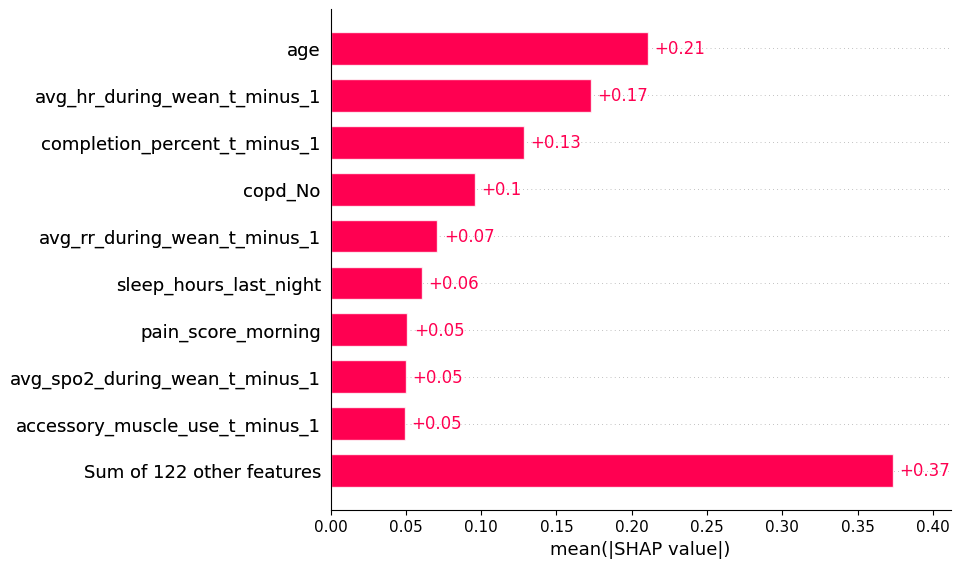

In [40]:
best_pipe_xgb.fit(X_train, y_train)

preprocessor = best_pipe_xgb.named_steps["columntransformer"]
xgb_model = best_pipe_xgb.named_steps["xgbclassifier"]

X_train_preprocessed = preprocessor.transform(X_train)

explainer = shap.TreeExplainer(xgb_model)
train_shap_values = explainer(X_train_preprocessed)

train_shap_values.feature_names = feature_names

shap.plots.bar(train_shap_values, max_display=10)

We can see that both models have indicated that age is the most important feature in making a prediction. 

The logistic regression model indicates that an increase of 1 scaled unit in age is associated with a relatively greater increase in the predicted log-odds that the patient failed their wean (our positive class).

# Reflection

I may come back and improve this notebook later. For now, I have already discussed how more attention needs to be paid to feature engineering and selection, because (again, ignoring that this is a synthetic dataset!) even the most sophisticated model, as shown, may not perform significantly better than random guessing if meaningful patterns cannot be generated from the features it has to work with.

There are undoubtedly data patterns that can help predict the likelihood of weaning failure in a given patient, but would be impossible for a clinician at the bedside to take full account of. A bedside tool that can scan a patient's chart, pull and preprocess relevant data, and output a likelihood of failure given the parameters for a given patient's wean would be helpful in terms of clinician awareness. 

One other issue is that model performance here was assessed using accuracy, which is not the most appropriate metric in this case. Given that in a clinical context we are more concerned about weaning failures and would tolerate some false positives, a metric like average precision, which is useful in cases of class imbalance when we care more about the positive class would have been more appropriate.